Heatmap saved as:
  - MDPI_abricate_9_01_2026.tif (600 DPI)

Heatmap dimensions: 28 sequences × 36 genes


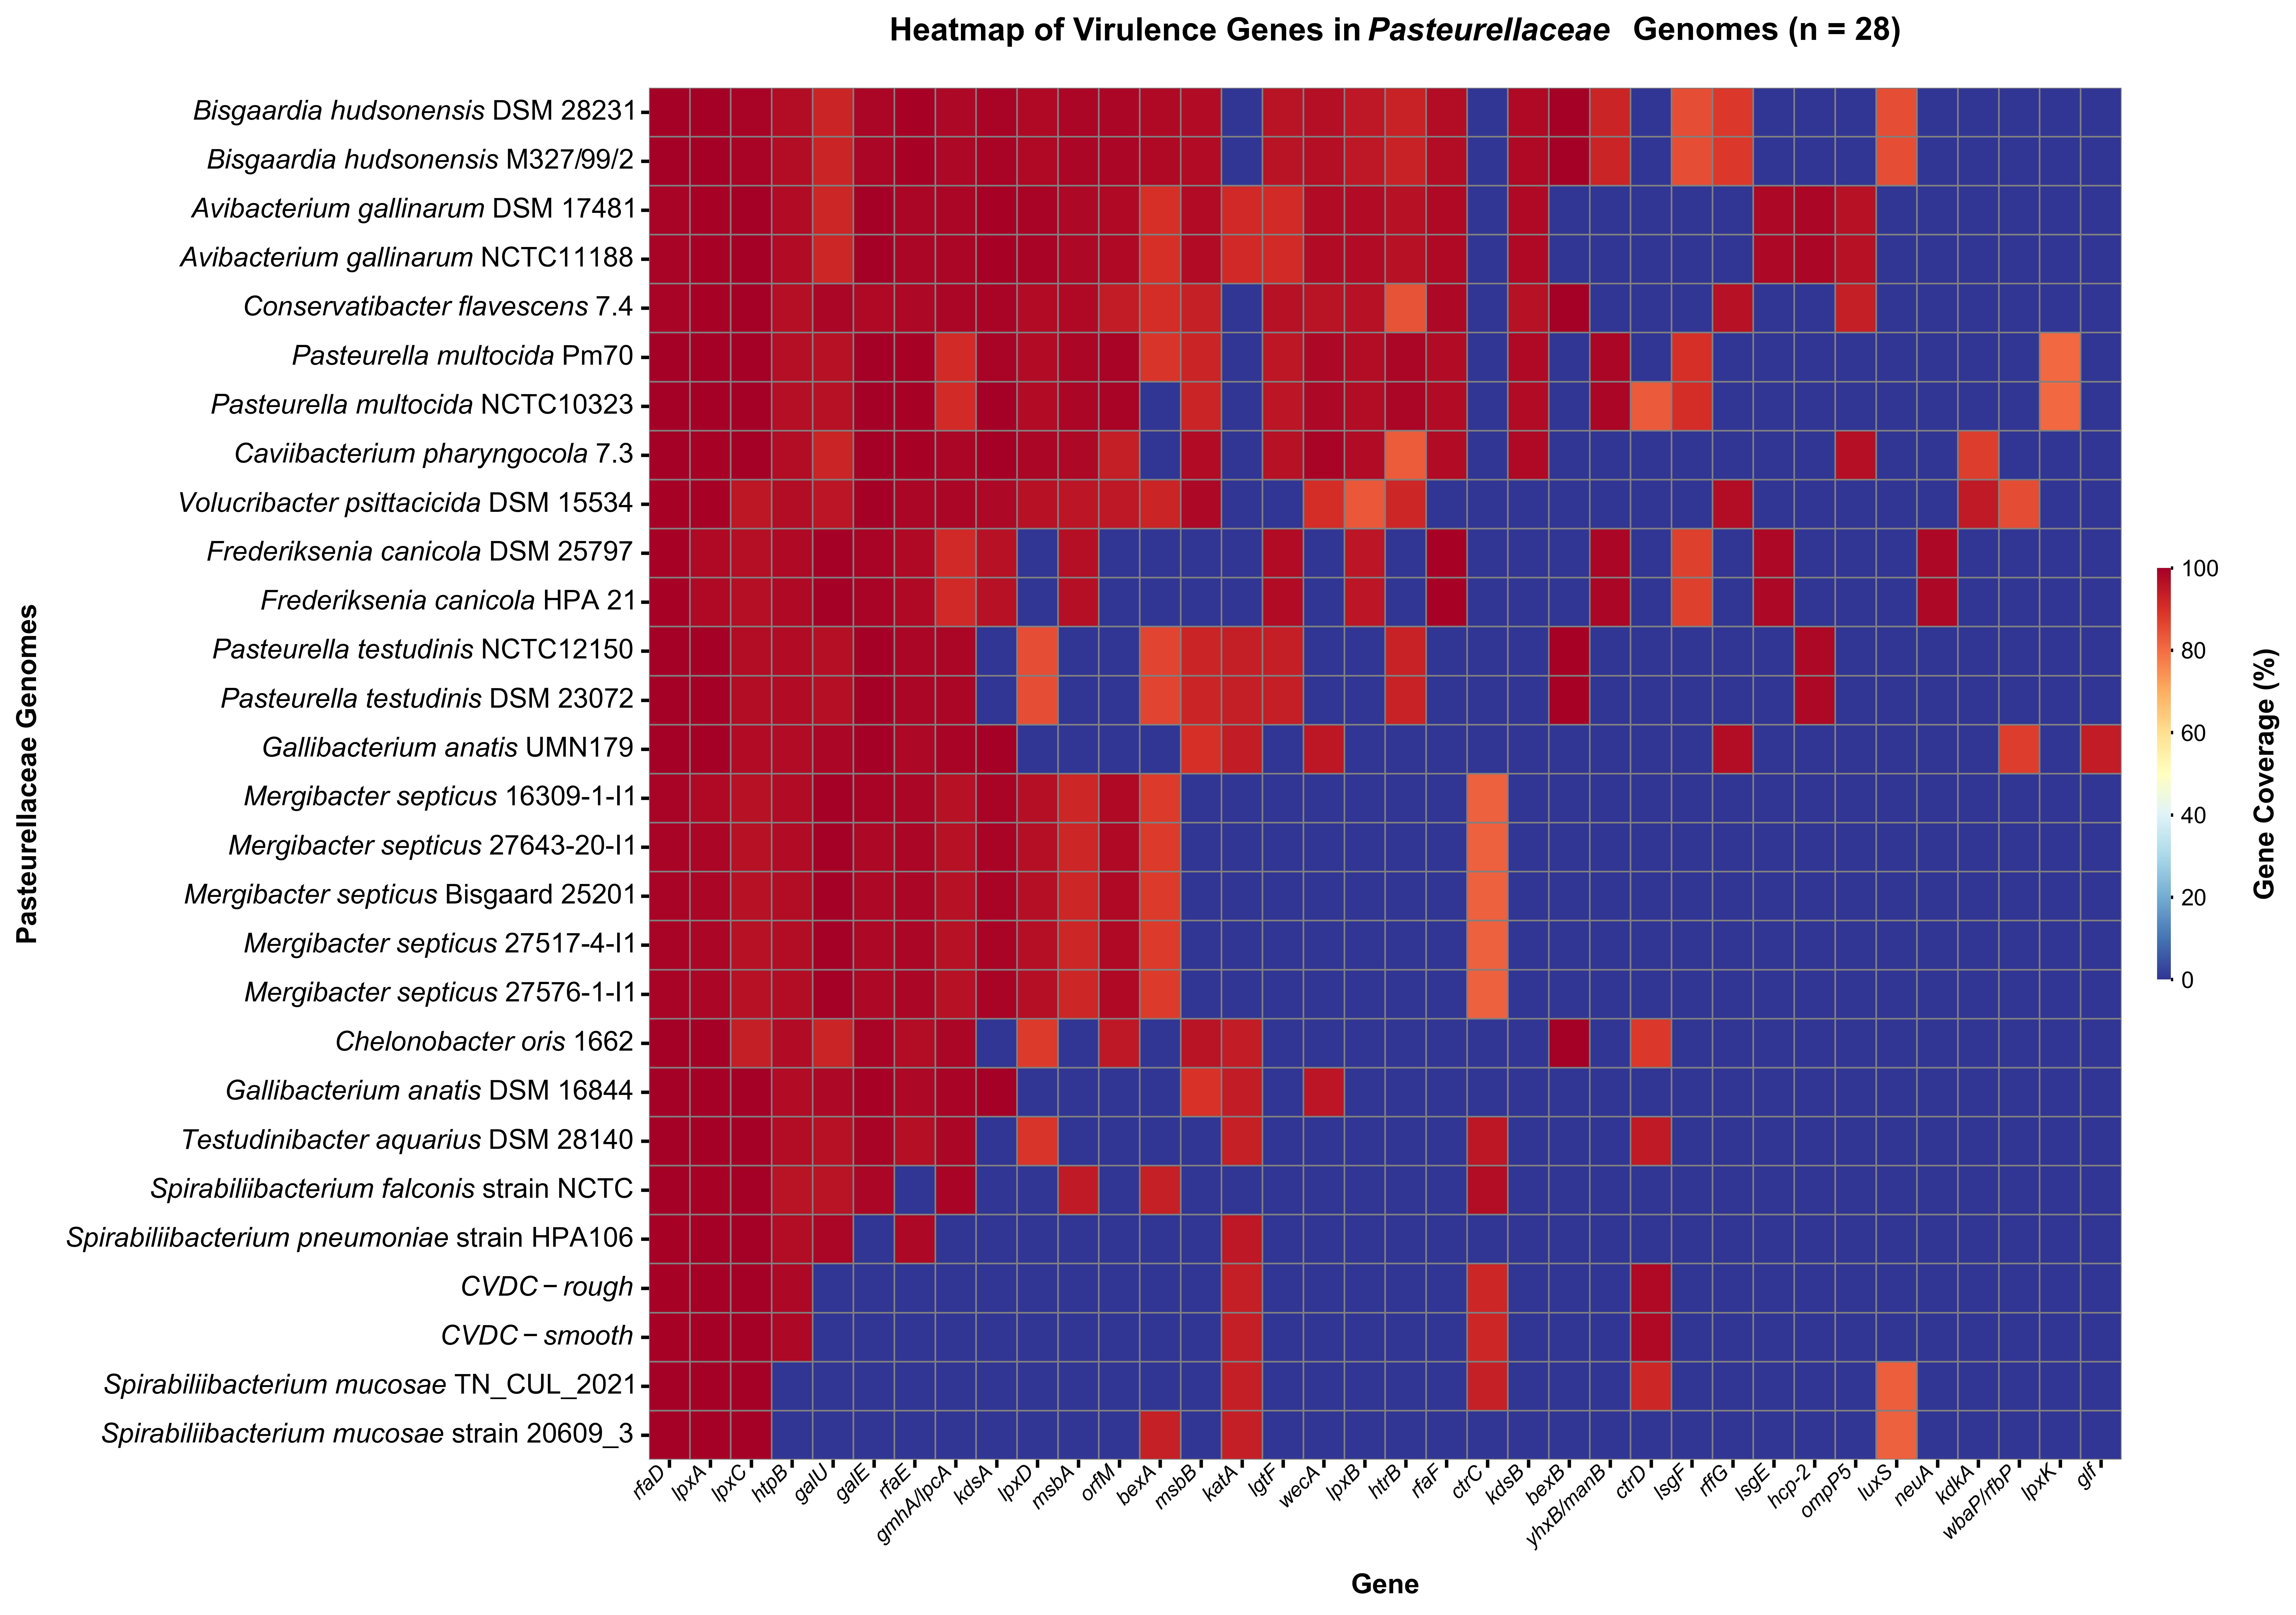

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Set publication-quality parameters
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['font.size'] = 14
rcParams['axes.linewidth'] = 1.5
rcParams['xtick.major.width'] = 1.5
rcParams['ytick.major.width'] = 1.5

# make mathtext ($\it{...}$) render as plain (non-bold) Arial italic
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.it'] = 'Arial:italic'
rcParams['mathtext.rm'] = 'Arial'

# Load the data
df = pd.read_csv("abricate_all_updated.csv", encoding="latin1")

# Group by 'ID' and 'GENE' and calculate the mean of '%COVERAGE'
df_grouped = df.groupby(['ID', 'GENE'], as_index=False)['%COVERAGE'].mean()

# Pivot the DataFrame to prepare it for the heatmap
heatmap_data = df_grouped.pivot(index="ID", columns="GENE", values="%COVERAGE")

# Replace NaN values with 0
heatmap_data = heatmap_data.fillna(0)

# Sort columns based on total sum of values (moving high-coverage genes to the left)
column_order = heatmap_data.sum(axis=0).sort_values(ascending=False).index
heatmap_data = heatmap_data[column_order]

# Sort rows by total coverage
row_order = heatmap_data.sum(axis=1).sort_values(ascending=False).index
heatmap_data = heatmap_data.loc[row_order]

# Create figure with specific size
fig, ax = plt.subplots(figsize=(15, 10), dpi=600)

# Generate heatmap with publication-ready styling
sns.heatmap(heatmap_data,
            cmap="RdYlBu_r",
            linewidths=0.5,
            linecolor='gray',
            annot=False,
            vmin=0,
            vmax=100,
            cbar_kws={
                'label': 'Gene Coverage (%)',
                'ticks': np.arange(0, 101, 20),
                'shrink': 0.3,
                'aspect': 30,
                'pad': 0.02
            },
            square=False,
            ax=ax)

# Customize colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10, width=1.5, length=1)
cbar.set_label('Gene Coverage (%)', fontsize=12, fontweight='bold', labelpad=15)

# --------------------------------------------------

# --------------------------------------------------
# TITLE — "Pasteurellaceae" bold + italic
# --------------------------------------------------

part1 = "Heatmap of Virulence Genes in"
part2 = "Pasteurellaceae"
part3 = "Genomes (n = 28)"

title_y = 1.03
fontsize = 14

# Explicit gap prevents overlap between rendered text objects
gap = 0.028  # axes-fraction units

t1 = ax.text(
    0, title_y, part1,
    fontsize=fontsize,
    fontfamily="Arial",
    fontweight="bold",
    fontstyle="normal",
    ha="left",
    va="bottom",
    transform=ax.transAxes
)

t2 = ax.text(
    0, title_y, part2,
    fontsize=fontsize,
    fontfamily="Arial",
    fontweight="bold",
    fontstyle="italic",
    ha="left",
    va="bottom",
    transform=ax.transAxes
)

t3 = ax.text(
    0, title_y, part3,
    fontsize=fontsize,
    fontfamily="Arial",
    fontweight="bold",
    fontstyle="normal",
    ha="left",
    va="bottom",
    transform=ax.transAxes
)

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

# Measure rendered widths in axes coordinates
def text_width(text_obj):
    bbox = text_obj.get_window_extent(renderer)
    bbox_axes = ax.transAxes.inverted().transform(bbox)
    return bbox_axes[1, 0] - bbox_axes[0, 0]

w1 = text_width(t1)
w2 = text_width(t2)
w3 = text_width(t3)

total_width = w1 + gap + w2 + gap + w3
start_x = 0.5 - total_width / 2

t1.set_position((start_x, title_y))
t2.set_position((start_x + w1 + gap, title_y))
t3.set_position((start_x + w1 + gap + w2 + gap, title_y))
ax.set_xlabel("Gene", fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel("Pasteurellaceae Genomes", fontsize=12, fontweight='bold', labelpad=10)

# --- ITALIC X-AXIS LABELS (Gene names) ---
ax.set_xticks(ax.get_xticks())  # fix tick positions before relabeling
ax.set_xticklabels(
    [label.get_text() for label in ax.get_xticklabels()],
    rotation=45,
    ha='right',
    fontsize=9,
    fontstyle='italic'   # <-- italic gene names
)

# --- ITALIC Y-AXIS LABELS (Species names) ---
# --- ITALIC Y-AXIS LABELS (Species names: only first two words italic) ---
ax.set_yticks(ax.get_yticks())

def format_species_label(name):
    parts = name.split()
    if len(parts) >= 2:
        # First two words (genus + species) in italic, rest normal
        italic_part = r'$\it{' + r'\ '.join(parts[:2]) + r'}$'
        normal_part = ' ' + ' '.join(parts[2:]) if len(parts) > 2 else ''
        return italic_part + normal_part
    return r'$\it{' + name + r'}$'

italic_yticklabels = [format_species_label(label.get_text()) 
                      for label in ax.get_yticklabels()]

ax.set_yticklabels(
    italic_yticklabels,
    rotation=0,
    fontsize=12
)

for label in ax.get_xticklabels():
    label.set_y(0.01)

# Adjust layout to prevent label cutoff
fig.subplots_adjust(top=0.90)  # reserve headroom for the title above axes
plt.tight_layout()

# Save figure
fig.savefig(
    "MDPI_abricate_9_01_2026.tif", 
    dpi=300, 
    bbox_inches='tight',
    format='tiff',
    pil_kwargs={"compression": "tiff_lzw"}
)


print("Heatmap saved as:")
print("  - MDPI_abricate_9_01_2026.tif (600 DPI)")
print(f"\nHeatmap dimensions: {heatmap_data.shape[0]} sequences × {heatmap_data.shape[1]} genes")

plt.show()